<a href="https://colab.research.google.com/github/chaithanyakamath/dlTask2/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 229kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.27MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.6MB/s]


In [2]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(-1, 1, 28, 28)

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [5]:
import os
os.makedirs("samples", exist_ok=True)

epochs = 10

for epoch in range(epochs):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z)

        D_fake = D(fake_imgs)
        loss_G = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1}: D Loss={loss_D.item():.4f}, G Loss={loss_G.item():.4f}")

    # Save images every epoch
    torchvision.utils.save_image(fake_imgs[:25], f"samples/epoch_{epoch+1}.png", nrow=5, normalize=True)

Epoch 1: D Loss=0.0371, G Loss=4.5499
Epoch 2: D Loss=0.0169, G Loss=6.4748
Epoch 3: D Loss=0.0356, G Loss=6.0990
Epoch 4: D Loss=0.1150, G Loss=7.2122
Epoch 5: D Loss=0.1370, G Loss=5.5113
Epoch 6: D Loss=0.0880, G Loss=3.9344
Epoch 7: D Loss=0.1095, G Loss=4.2006
Epoch 8: D Loss=0.1349, G Loss=3.0585
Epoch 9: D Loss=0.3651, G Loss=3.2115
Epoch 10: D Loss=0.2010, G Loss=2.6037


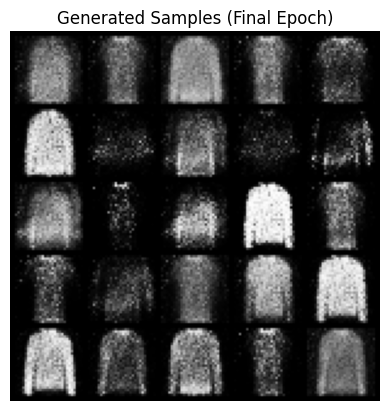

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("samples/epoch_10.png")
plt.imshow(img)
plt.axis('off')
plt.title("Generated Samples (Final Epoch)")
plt.show()

In [8]:
import os
os.makedirs("samples", exist_ok=True)

G_losses = []
D_losses = []

epochs = 10

for epoch in range(epochs):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = G(z)

        D_fake = D(fake_imgs)
        loss_G = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(f"Epoch {epoch+1}: D Loss={loss_D.item():.4f}, G Loss={loss_G.item():.4f}")

    # Save images every epoch
    torchvision.utils.save_image(fake_imgs[:25], f"samples/epoch_{epoch+1}.png", nrow=5, normalize=True)

Epoch 1: D Loss=0.3337, G Loss=3.4834
Epoch 2: D Loss=0.7539, G Loss=3.0552
Epoch 3: D Loss=0.9169, G Loss=2.6823
Epoch 4: D Loss=0.4983, G Loss=3.6273
Epoch 5: D Loss=0.2123, G Loss=3.9517
Epoch 6: D Loss=0.3327, G Loss=2.9710
Epoch 7: D Loss=0.2982, G Loss=2.8598
Epoch 8: D Loss=0.2386, G Loss=3.8162
Epoch 9: D Loss=0.5218, G Loss=2.8906
Epoch 10: D Loss=0.3192, G Loss=2.8133
